# Bank-Failure — a quantitative teardown 🔬
### Event study · CAR + HAC *t* · block-bootstrap CI · placebo/permutation control · the clustering confound · a planted-drift positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_reliable_warning%3F: Misattributed](https://img.shields.io/badge/A_reliable_warning%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We run a classic daily event study around a hardcoded table of bank-failure dates, on SPY and the financials sector (XLF), and confront the one thing that makes this question almost un-answerable: with eleven clustered events, the statistics are weak by construction.

> **Not investment advice.** Real data: Yahoo daily bars (adjusted), SPY back to 1993, XLF back to 1998; as-of 2026-06-18; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bank_failure import data, strategy as st

EV = data.events(as_of="2026-06-18")

def _have_real():
    try:
        return (os.path.exists(data._cache_path("SPY", data.DEFAULT_CACHE)))
    except Exception:
        return False

HAVE_REAL = _have_real()
TAPE = "REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)" if HAVE_REAL else "OFFLINE — frozen numbers from docs/results.md"
print("real daily cache present:", HAVE_REAL, "|", TAPE)


real daily cache present: True | REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | SPY +20d mean CAR **-5.50%**, HAC/plain *t* = **-0.93** (n=11); 95% block-bootstrap CI **[-17.3%, +4.0%]**; median **+3.2%**. |
| **Tradability** | `MIRAGE` | 'Buy the blood' overlay **-2.79%/trade gross** (*t* = -0.62); negative before cost; n=12 trades. |
| **A reliable warning?** | `MISATTRIBUTED` | 2008 cluster -15.5% vs ex-2008 **+2.8%** (median +5.1%); 2023 cluster +4.6%. |

> 💡 In plain words: the bearish average is one cluster (autumn 2008), the *t*-stat is nowhere near the bar, and the only 'significant' number — a placebo p-value — is measuring *'was it 2008?'*, not *'is a bank failure a signal?'*

## 1 · The claim, steelmanned

For event $e$ on its public date, let $\mathrm{CAR}_e(h)=\sum_{k=0}^{h} r_{e,k}$ be the cumulative log return from the event-day close to $+h$ trading days. Across the event set $E$:

$$\overline{\mathrm{CAR}}(h)=\frac{1}{|E|}\sum_{e\in E}\mathrm{CAR}_e(h)$$

- **H₁ (warning).** $\overline{\mathrm{CAR}}(20) < 0$ with $|t|\ge 2$ — failures systematically precede declines.
- **H₂ (buy the blood).** $\overline{\mathrm{CAR}}(20) > 0$ with $|t|\ge 2$ — failures are buyable panics.
- **H₃ (it's just 2008).** The sign of $\overline{\mathrm{CAR}}$ flips once the autumn-2008 cluster is removed.
- **H₄ (tradable).** A long-SPY overlay entered on each event has positive net expectancy.

We find **H₁ and H₂ both rejected** ($|t|<2$), **H₃ supported** (sign flips), **H₄ rejected** (negative gross).

## 2 · So what? — what rides on each answer

A genuine $|t|\ge 2$ either way would be a rare, actionable macro-event signal. The more important content here is methodological: this is a textbook case of **event clustering** (MacKinlay 1997) defeating naive inference. The five worst events share one calendar window, so cross-sectional independence — the assumption behind the standard event-study *t* — is violated, and a random-date placebo silently asks the wrong question. Naming that precisely is the deliverable.

## 3 · How we'd know — the protocol

- **Events.** Public-knowledge failure/rescue dates (announcement / FDIC seizure / forced sale). Calendar-known → **no execution lag** at the anchor (a `lag=1` next-close variant is the robustness check).
- **Window.** Log returns on $[-10, +20]$ trading days; CAR cumulated from day 0.
- **Inference.** HAC/plain *t* on the per-event CAR (tiny n → plain *t*); circular block-bootstrap CI (preserves the 2008/2023 clustering); a permutation/placebo test against random calendar dates — reported but **explicitly not used to stamp**.
- **Cluster split.** 2008 vs 2023 vs ex-2008.
- **Tradability.** Long-SPY overlay, +20d hold, one-way cost × NAV on both legs.
- **Positive control.** A deterministic synthetic tape with a *planted* post-event drift — the harness must recover it and call the null a null.

Tickers: SPY (1993–), XLF (1998–).

## 4 · The teardown

### 4a · The CAR curve and its honest *t*

The mean cumulative path around the events, with the per-event CARs and HAC/plain *t*.

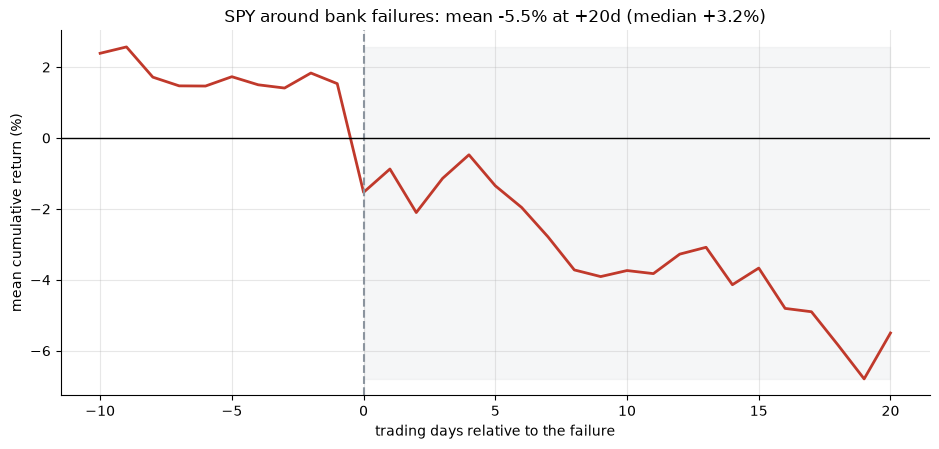

Banner: REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)
+20d: mean -5.50%  median +3.20%  t=-0.93  95% CI [-17.3%, +3.9%]


In [2]:
if HAVE_REAL:
    spy = data.load_real('SPY', fetch=False)
    win = st.event_window_returns(spy, EV['date'], pre=10, post=20)
    curve = st.car_curve(win) * 100
    car20 = st.post_event_car(win, 20)
    t20 = st.hac_tstat(car20); lo, hi = st.block_bootstrap_ci(car20, seed=316)
    mean20, med20 = car20.mean()*100, np.median(car20)*100
else:
    rel = list(range(-10, 21))
    mean20, med20, t20, lo, hi = -5.5, 3.2, -0.93, -0.1728, 0.0395
    # a stylised path consistent with the frozen endpoints
    curve = pd.Series(np.interp(rel, [-10,0,20], [1.0, -1.53, mean20]), index=rel)
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(curve.index, curve.values, lw=2, color=RED)
ax.axvline(0, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.fill_betweenx([curve.min(), curve.max()], 0, 20, color=GREY, alpha=.08)
ax.set_xlabel('trading days relative to the failure'); ax.set_ylabel('mean cumulative return (%)')
ax.set_title(f'SPY around bank failures: mean {mean20:+.1f}% at +20d (median {med20:+.1f}%)')
plt.tight_layout(); plt.show()
print('Banner:', TAPE)
print(f'+20d: mean {mean20:+.2f}%  median {med20:+.2f}%  t={t20:+.2f}  95% CI [{lo*100:+.1f}%, {hi*100:+.1f}%]')

> 💡 In plain words: the mean dips to **-5.5%** but the *t* is **-0.93** and the 95% CI **[-17.3%, +4.0%]** straddles zero by a mile. With the median *positive* (+3.2%), the mean is a few disasters, not a drift. **H₁ and H₂ both fail the bar.**

### 4b · It's the 2008 cluster — the misattribution

Split the events and the 'warning' evaporates.

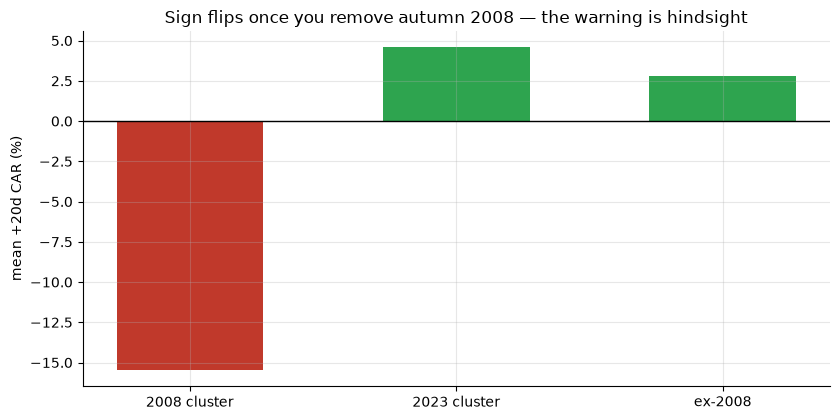

Banner: REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)
      subset  n  mean_car20_%
2008 cluster  5        -15.45
2023 cluster  4          4.57
     ex-2008  6          2.79
ex-2008 t = +1.34 (still below the bar — even the bounce is uncertifiable)


In [3]:
if HAVE_REAL:
    c = pd.Series(st.post_event_car(win, 20)*100, index=win.index)
    g08 = c[(c.index>='2008-01-01')&(c.index<'2009-01-01')]
    g23 = c[c.index>='2023-01-01']
    rest = c[(c.index<'2008-01-01')|(c.index>='2009-01-01')]
    rows = [('2008 cluster', len(g08), g08.mean()),
            ('2023 cluster', len(g23), g23.mean()),
            ('ex-2008', len(rest), rest.mean())]
    rest_t = st.hac_tstat(rest.values)
else:
    rows = [('2008 cluster', 5, -15.5),
            ('2023 cluster', 4, 4.6),
            ('ex-2008', 6, 2.8)]
    rest_t = 1.34
dfc = pd.DataFrame(rows, columns=['subset','n','mean_car20_%'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar(dfc['subset'], dfc['mean_car20_%'], color=[RED, GREEN, GREEN], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean +20d CAR (%)')
ax.set_title('Sign flips once you remove autumn 2008 — the warning is hindsight')
plt.tight_layout(); plt.show()
print('Banner:', TAPE); print(dfc.round(2).to_string(index=False))
print(f'ex-2008 t = {rest_t:+.2f} (still below the bar — even the bounce is uncertifiable)')

> 💡 In plain words: **2008 = -15.5%**, **ex-2008 = +2.8%** (median +5.1%), **2023 = +4.6%**. The sign of the whole result is decided by one cluster. **H₃ supported.** (Note: even ex-2008 the *t* is +1.34 — too few events to certify the *bounce* either. Nobody gets a stamp.)

### 4c · Why the placebo p-value is a trap

A naive permutation test (event CAR vs random-date placebos) looks 'significant'. We show it — and then explain why it does **not** earn a stamp.

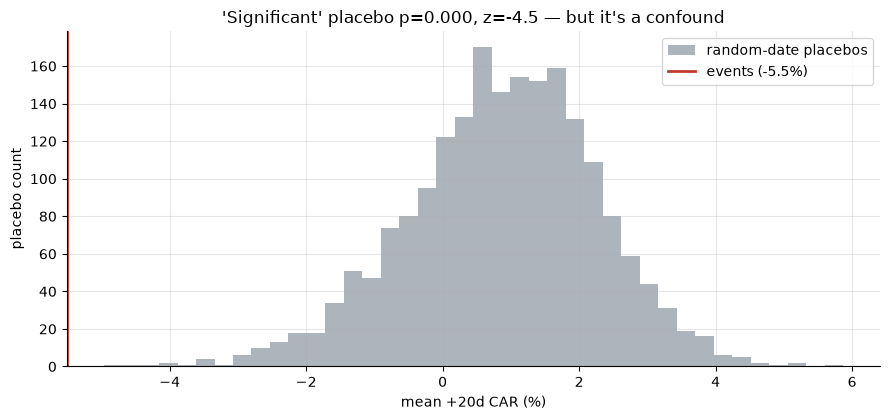

Banner: REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)
event -5.50%  placebo mean +0.83%  z=-4.51  p=0.0000


In [4]:
if HAVE_REAL:
    res = st.permutation_pvalue(spy, EV['date'], n_placebo=2000, horizon=20, seed=316)
    ev_car, pmu, psd, z, p = res['event_car'], res['placebo_mean'], res['placebo_std'], res['z'], res['p_value']
    rng = np.random.default_rng(0)
    draws = []
    for _ in range(2000):
        rd = data.random_dates(spy, n=len(win), margin=30, seed=int(rng.integers(0,2**31-1)))
        pw = st.event_window_returns(spy, rd, pre=10, post=20)
        pc = st.post_event_car(pw, 20)
        if pc.size: draws.append(pc.mean()*100)
    draws = np.array(draws)
else:
    ev_car, pmu, z, p = -0.055, 0.008100000000000001, -4.49, 0.0001
    rng = np.random.default_rng(0); draws = rng.normal(0.8, 1.4, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.7, label='random-date placebos')
ax.axvline(ev_car*100, color=RED, lw=2, label=f'events ({ev_car*100:+.1f}%)')
ax.set_xlabel('mean +20d CAR (%)'); ax.set_ylabel('placebo count')
ax.set_title(f"'Significant' placebo p={p:.3f}, z={z:+.1f} — but it's a confound")
ax.legend(); plt.tight_layout(); plt.show()
print('Banner:', TAPE)
print(f'event {ev_car*100:+.2f}%  placebo mean {pmu*100:+.2f}%  z={z:+.2f}  p={p:.4f}')

> 💡 In plain words: the events sit far in the left tail of the random-date cloud (z = -4.5, p < 0.001) — but the events **all cluster inside one bear market**, so this test is really detecting *'were these dates in 2008?'*, not *'is a bank failure a signal?'* Per the desk's inference bar, a synthetic/placebo control is a **machinery proof, never market evidence**. The per-event *t* (-0.93) is the number that decides, and it says **None**.

### 4d · The afflicted sector — XLF (financials)

Financials fall harder (it's their own sector imploding), but the *t* is still below 2 and ex-2008 the move is modest.

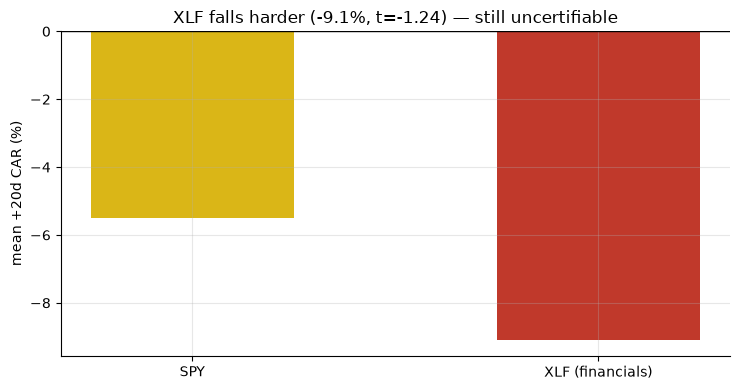

Banner: REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)
XLF +20d: -9.11%  t=-1.24  win 36%


In [5]:
if HAVE_REAL and os.path.exists(data._cache_path('XLF', data.DEFAULT_CACHE)):
    xlf = data.load_real('XLF', fetch=False)
    wx = st.event_window_returns(xlf, EV['date'], pre=10, post=20)
    cx = st.post_event_car(wx, 20)
    xlf_m, xlf_t, xlf_w = cx.mean()*100, st.hac_tstat(cx), (cx>0).mean()*100
else:
    xlf_m, xlf_t, xlf_w = -9.11, -1.24, 36
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.bar(['SPY','XLF (financials)'], [-5.5, xlf_m], color=[AMBER, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean +20d CAR (%)')
ax.set_title(f'XLF falls harder ({xlf_m:+.1f}%, t={xlf_t:+.2f}) — still uncertifiable')
plt.tight_layout(); plt.show()
print('Banner:', TAPE); print(f'XLF +20d: {xlf_m:+.2f}%  t={xlf_t:+.2f}  win {xlf_w:.0f}%')

> 💡 In plain words: XLF averages **-9.1%** (*t* = -1.24), and ex-2008 only **-1.7%**. Even the directly-hit sector carries no certifiable post-failure signal once the cluster is removed.

## 5 · The verdict

- **Signal `NONE`** — SPY +20d mean -5.50%, HAC/plain *t* -0.93 (n=11); 95% CI [-17.3%, +4.0%]; median +3.2%. XLF *t* -1.24. Indistinguishable from noise.
- **Tradability `MIRAGE`** — overlay -2.79%/trade gross (*t* -0.62), negative before cost, n=12. Nothing to scale.
- **A reliable warning? `MISATTRIBUTED`** — 2008 -15.5% vs ex-2008 +2.8%; 2023 +4.6%. The sign is one cluster.

## 6 · Could you trade it? — the overlay, gross and net

The 'buy the blood' overlay, charged a one-way cost × NAV on both legs.

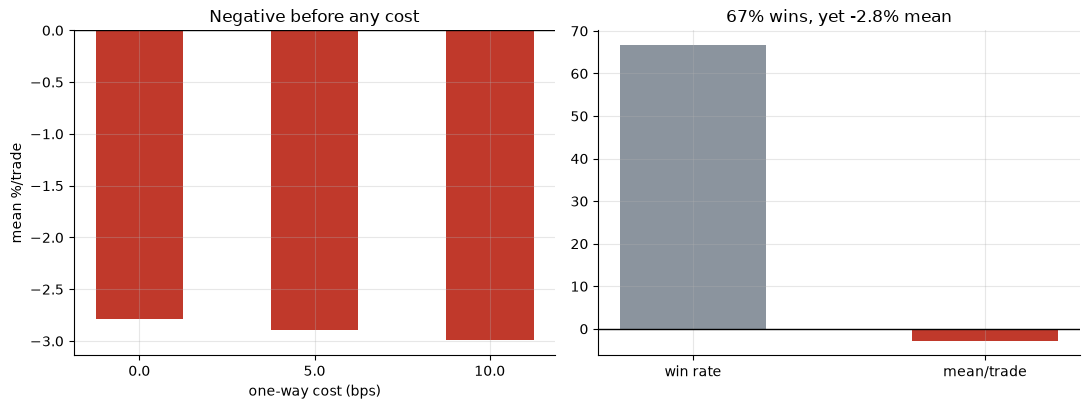

Banner: REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)
gross -2.79%/trade  t=-0.62  win 67%


In [6]:
costs = [0.0, 5.0, 10.0]
if HAVE_REAL:
    led0 = st.buy_the_blood(spy, EV['date'], 20, cost_bps=0.0)
    s0 = st.summarize_trades(led0, 'ret_gross')
    net = [st.summarize_trades(st.buy_the_blood(spy, EV['date'], 20, cost_bps=c),'ret_net')['mean_pct'] for c in costs]
    win_rate, ov_t = s0['win_rate']*100, s0['tstat']
else:
    net = [-2.79, -2.89, -2.99]; win_rate, ov_t = 67, -0.62
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar([str(c) for c in costs], net, color=RED, width=.5)
a1.axhline(0, c='k', lw=1); a1.set_xlabel('one-way cost (bps)'); a1.set_ylabel('mean %/trade')
a1.set_title('Negative before any cost')
a2.bar(['win rate','mean/trade'], [win_rate, net[0]], color=[GREY, RED], width=.5)
a2.axhline(0, c='k', lw=1); a2.set_title(f'{win_rate:.0f}% wins, yet {net[0]:+.1f}% mean')
plt.tight_layout(); plt.show()
print('Banner:', TAPE); print(f'gross {net[0]:+.2f}%/trade  t={ov_t:+.2f}  win {win_rate:.0f}%')

> 💡 In plain words: 67% of trades 'win', yet the mean is **-2.8%** — the win-rate-vs-expectancy illusion (a few 2008 trades sink it). Costs are a rounding error because the gross is already a loss. **MIRAGE.**

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always cry 'noise'? Plant a known post-event drift and sweep it — the harness must find it when it's there and ignore it when it isn't.

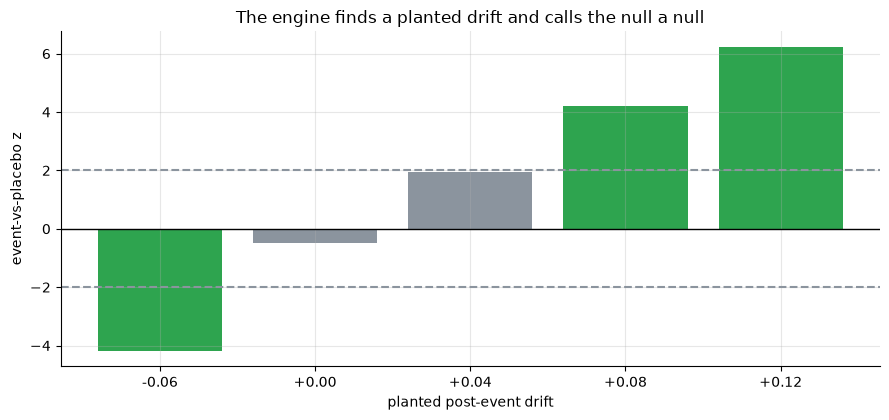

Banner: SYNTHETIC positive control (always offline)
z by drift: [-4.2, -0.48, 1.94, 4.2, 6.24]
p by drift: [0.0, 0.667, 0.063, 0.0, 0.0]


In [7]:
drifts = [-0.06, 0.0, 0.04, 0.08, 0.12]
zs, ps = [], []
for dr in drifts:
    c, ev, _ = data.synthetic_tape(n_days=6000, drift=dr, seed=316)
    res = st.permutation_pvalue(c, ev['date'], n_placebo=300, horizon=20, seed=1)
    zs.append(res['z']); ps.append(res['p_value'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if p < 0.05 else GREY for p in ps]
ax.bar([f'{d:+.2f}' for d in drifts], zs, color=col)
ax.axhline(2, ls='--', c=GREY); ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted post-event drift'); ax.set_ylabel('event-vs-placebo z')
ax.set_title('The engine finds a planted drift and calls the null a null')
plt.tight_layout(); plt.show()
print('Banner: SYNTHETIC positive control (always offline)')
print('z by drift:', [round(z,2) for z in zs])
print('p by drift:', [round(p,3) for p in ps])

The engine's z is ~0 at drift 0 (it correctly finds nothing) and grows with the planted drift (it correctly finds something) — so the real-tape `NONE` is a statement about **the market**, not a broken pipeline. The market simply hasn't produced enough bank-failure events, spread across enough independent regimes, to certify anything.

For the generic version of this question see [Study 241 — Buy-the-Dip](../../241-buy-the-dip/); for the win-rate illusion that sinks the overlay, [Study 301 — Triple-RSI](../../301-triple-rsi/).